In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
os.chdir("C:\\Users\\Vikas\\Downloads")

air = pd.read_csv("air_quality.csv")
heart = pd.read_csv("heart.csv")

In [4]:
# 3. Data Cleaning
air.columns = air.columns.str.strip()
heart.columns = heart.columns.str.strip()

# Handle missing values
air = air.dropna()
heart = heart.fillna(heart.mean(numeric_only=True))

# Remove duplicates
air = air.drop_duplicates()
heart = heart.drop_duplicates()


In [5]:
# 4. Data Integration
if isinstance(air.columns, pd.MultiIndex):
    air.columns = air.columns.get_level_values(0)

if isinstance(heart.columns, pd.MultiIndex):
    heart.columns = heart.columns.get_level_values(0)

# Reset index
air = air.reset_index(drop=True)
heart = heart.reset_index(drop=True)

# Combine datasets
data = pd.concat([air, heart], axis=1)

print("Integrated Data Sample:")
print(data.head())


Integrated Data Sample:
  Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;  \
0                                             7578;;                                                                             
1                                             7502;;                                                                             
2                                             7867;;                                                                             
3                                             7888;;                                                                             
4                                             7848;;                                                                             

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  52.0  1.0  0.0     125.0  212.0  0.0      1.0    168.0    0.0      1.0   
1  53.0  1.0  0.0     140.0  203.0  1.0  

In [6]:
# 5. Data Transformation
if 'PM2.5' in data.columns:
    data['PM2.5'] = (data['PM2.5'] - data['PM2.5'].min()) / \
                   (data['PM2.5'].max() - data['PM2.5'].min())

# Convert categorical to numeric
data = pd.get_dummies(data, drop_first=True)

In [7]:
# 6. Error Correction
for col in data.select_dtypes(include=np.number).columns:
    data[col] = data[col].apply(lambda x: abs(x))

# Remove unrealistic age values
if 'age' in data.columns:
    data = data[data['age'] <= 100]

print("\nData Description:")
print(data.describe())


Data Description:
             age         sex          cp    trestbps        chol         fbs  \
count  302.00000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean    54.42053    0.682119    0.963576  131.602649  246.500000    0.149007   
std      9.04797    0.466426    1.032044   17.563394   51.753489    0.356686   
min     29.00000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.00000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.50000    1.000000    1.000000  130.000000  240.500000    0.000000   
75%     61.00000    1.000000    2.000000  140.000000  274.750000    0.000000   
max     77.00000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.526490  149.569536    0.327815    1.043046    1.397351    0.718543   
std      0.526027

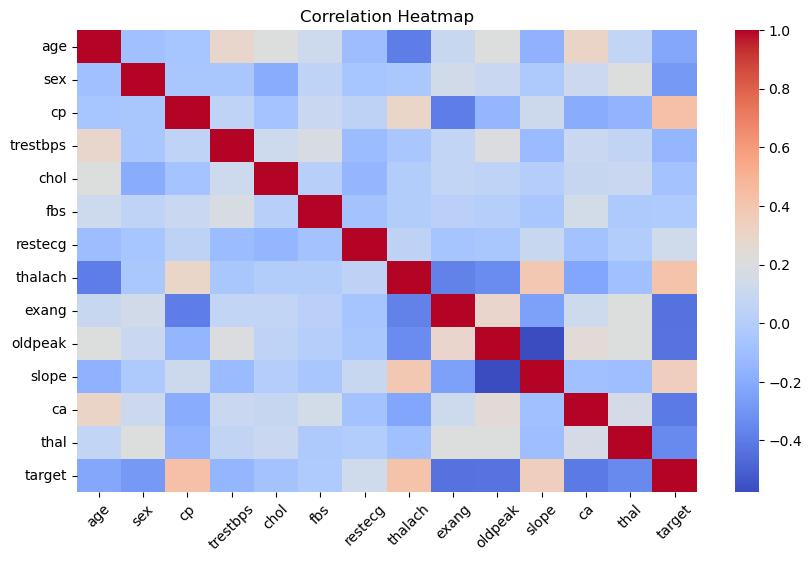

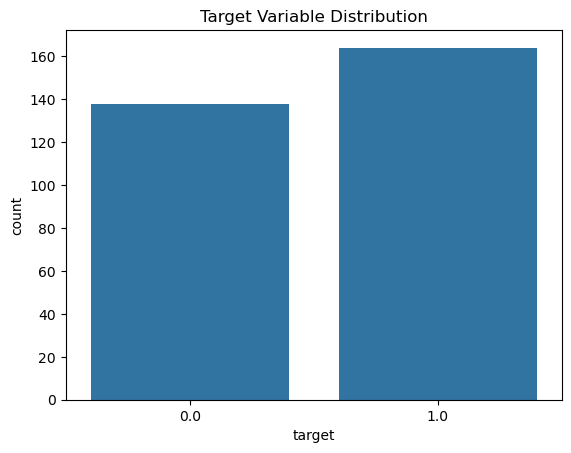

In [10]:
# Heatmap
plt.figure(figsize=(10,6))

# Select only numeric columns
corr = data.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

# Target count plot
if 'target' in data.columns:
    sns.countplot(x='target', data=data)
    plt.title("Target Variable Distribution")
    plt.show()